# S13 – Тонкая настройка BERT для классификации текста

В этом ноутбуке переходим от **готового инференса** к следующему шагу:  
будем **дообучать BERT-подобную модель под собственную задачу классификации текста**.

Идея здесь простая:

1. у нас есть размеченные тексты;
2. мы токенизируем их так, как ожидает трансформер;
3. загружаем предобученную модель;
4. добавляем/инициализируем классификационную голову;
5. дообучаем модель на своей задаче;
6. оцениваем качество и разбираем ошибки.

Чтобы ноутбук оставался компактным и быстро запускался на учебной машине,  
используем **небольшой учебный датасет** и **компактную русскоязычную BERT-подобную модель**.

> Здесь цель – не получить state-of-the-art, а **понять полный инженерный pipeline fine-tuning**.


## 0. План

К концу ноутбука надо уметь:

1. Подготовить небольшой датасет классификации текста.
2. Разбить данные на `train / validation / test`.
3. Преобразовать данные в формат `datasets.DatasetDict`.
4. Выполнить токенизацию с помощью `AutoTokenizer`.
5. Загрузить `AutoModelForSequenceClassification`.
6. Настроить `Trainer` и запустить fine-tuning.
7. Посчитать метрики качества и проверить модель на новых примерах.
8. Разобрать типичные ошибки модели и понять, от чего зависит качество.


## 1. Импорты и общие настройки

Ниже подключаем библиотеки, фиксируем `seed`, выбираем устройство и настраиваем удобный вывод.

> Предполагается, что в окружении уже доступны `torch`, `transformers`, `datasets`, `accelerate`, `scikit-learn`, `pandas`, `numpy` и `matplotlib`.


In [ ]:
# Базовые библиотеки для воспроизводимости, анализа и визуализации.
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)


In [ ]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 2. Учебный датасет и постановка задачи

Для демонстрации возьмём **небольшой размеченный русскоязычный датасет** из трёх тематических классов:

- `education` – образование, курсы, университет, обучение;
- `technology` – ИТ, модели, код, сервисы, цифровые продукты;
- `sports` – спорт, матчи, тренировки, команды, соревнования.

Такой датасет удобно держать прямо в ноутбуке:

- он прозрачен;
- его легко читать и модифицировать;
- обучение идёт быстро;
- весь pipeline виден целиком.

При этом важно помнить: это **учебный датасет**, поэтому итоговые метрики не надо воспринимать как «боевое качество».


In [ ]:
# Небольшой учебный датасет: короткие тексты и тематические метки.
samples = [
    # education
    ("На лекции подробно разобрали градиентный спуск и регуляризацию.", "education"),
    ("Студенты сдали домашнее задание по Python и анализу данных.", "education"),
    ("В университете открыли новую магистерскую программу по искусственному интеллекту.", "education"),
    ("Преподаватель объяснил, как работает кросс-валидация на практических примерах.", "education"),
    ("Курс по машинному обучению включает семинары, лабораторные и итоговый проект.", "education"),
    ("На занятии обсуждали переобучение модели и способы его уменьшить.", "education"),
    ("Школьники готовятся к олимпиаде по информатике и решают сложные задачи.", "education"),
    ("На семинаре мы сравнивали разные архитектуры нейронных сетей.", "education"),
    ("Экзамен по статистике пройдёт в письменной форме на следующей неделе.", "education"),
    ("Студент защитил проект по компьютерному зрению и получил высокий балл.", "education"),
    ("Для курса требуется базовое знание линейной алгебры и теории вероятностей.", "education"),
    ("В лаборатории обсуждали метрики качества классификации и матрицу ошибок.", "education"),
    ("Программа дополнительного образования рассчитана на специалистов из отрасли.", "education"),
    ("На консультации преподаватель помог исправить ошибки в ноутбуке с кодом.", "education"),
    ("Группа изучает токенизацию, attention и тонкую настройку трансформеров.", "education"),

    # technology
    ("Разработчики выкатили новую версию сервиса с улучшенным API и логированием.", "technology"),
    ("Модель обрабатывает текстовые запросы и возвращает структурированный ответ.", "technology"),
    ("Команда настроила CI/CD и автоматическую проверку качества кода.", "technology"),
    ("Инженеры оптимизировали инференс, чтобы сократить задержку ответа модели.", "technology"),
    ("В репозитории обновили зависимости и зафиксировали версии библиотек.", "technology"),
    ("Сервис развёрнут в контейнерах и использует очередь задач для фоновой обработки.", "technology"),
    ("Система мониторинга показывает рост загрузки GPU во время обучения модели.", "technology"),
    ("Разработчик добавил поддержку векторного поиска и работу с эмбеддингами.", "technology"),
    ("В приложении исправили ошибку сериализации JSON и проблему с кодировкой.", "technology"),
    ("Инженер описал архитектуру проекта, схему данных и правила деплоя.", "technology"),
    ("Стенд демонстрирует работу RAG-системы с поиском по внутренним документам.", "technology"),
    ("После обновления библиотек код стал работать быстрее и стабильнее.", "technology"),
    ("Модель классификации текста обучается в PyTorch и сохраняется в формате safetensors.", "technology"),
    ("Команда подключила трекинг экспериментов и хранение метрик обучения.", "technology"),
    ("Прототип использует токенизатор HuggingFace и BERT-подобную языковую модель.", "technology"),

    # sports
    ("Команда уверенно выиграла матч и поднялась на первое место в таблице.", "sports"),
    ("Тренер похвалил игроков за дисциплину и хорошую игру в обороне.", "sports"),
    ("Футболисты провели интенсивную тренировку перед важной встречей.", "sports"),
    ("На стадионе сегодня аншлаг: болельщики ждут принципиального дерби.", "sports"),
    ("Спортсмен улучшил личный рекорд и вышел в финал соревнований.", "sports"),
    ("Во втором тайме команда прибавила в скорости и переломила ход игры.", "sports"),
    ("Судья назначил пенальти в концовке матча, и трибуны взорвались эмоциями.", "sports"),
    ("Клуб объявил состав на сезон и представил нового главного тренера.", "sports"),
    ("После серии поражений команда наконец одержала долгожданную победу.", "sports"),
    ("Игрок пропустит следующий матч из-за травмы колена.", "sports"),
    ("Сборная успешно начала турнир и не пропустила ни одного мяча.", "sports"),
    ("Баскетболисты хорошо двигали мяч и уверенно реализовали дальние броски.", "sports"),
    ("Хоккейный вратарь несколько раз спас команду в очень сложных эпизодах.", "sports"),
    ("На марафоне участники держали высокий темп почти всю дистанцию.", "sports"),
    ("В решающем сете теннисист сыграл хладнокровно и довёл матч до победы.", "sports"),
]

df = pd.DataFrame(samples, columns=["text", "label"])
df.head()


,text,label
0,На лекции подробно разобрали градиентный спуск и регуляризацию.,education
1,Студенты сдали домашнее задание по Python и анализу данных.,education
2,В университете открыли новую магистерскую программу по искусственному интеллекту.,education
3,"Преподаватель объяснил, как работает кросс-валидация на практических примерах.",education
4,"Курс по машинному обучению включает семинары, лабораторные и итоговый проект.",education


In [ ]:
# Смотрим размер датасета и распределение по классам.
print("Размер датасета:", len(df))
display(df["label"].value_counts())

label_names = sorted(df["label"].unique())
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

df["label_id"] = df["label"].map(label2id)

print("label2id:", label2id)
print("id2label:", id2label)

display(df.sample(6, random_state=42).reset_index(drop=True))


Размер датасета: 45


,count
label,
education,15
technology,15
sports,15


label2id: {'education': 0, 'sports': 1, 'technology': 2}
id2label: {0: 'education', 1: 'sports', 2: 'technology'}


,text,label,label_id
0,Игрок пропустит следующий матч из-за травмы колена.,sports,1
1,Стенд демонстрирует работу RAG-системы с поиском по внутренним документам.,technology,2
2,После обновления библиотек код стал работать быстрее и стабильнее.,technology,2
3,На марафоне участники держали высокий темп почти всю дистанцию.,sports,1
4,Во втором тайме команда прибавила в скорости и переломила ход игры.,sports,1
5,Баскетболисты хорошо двигали мяч и уверенно реализовали дальние броски.,sports,1


## 3. Разбиение на `train / validation / test`

Используем двухэтапное разбиение:

1. сначала отделяем тестовую выборку;
2. затем из оставшейся части выделяем валидацию.

Параметр `stratify` нужен для того, чтобы **сохранять баланс классов** в каждой подвыборке.


In [ ]:
# Сначала отделяем test (20%), затем из оставшихся данных выделяем validation (25% от остатка),
# что в итоге даёт приблизительно 60/20/20.
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"],
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=42,
    stratify=train_df["label_id"],
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nРаспределение классов в train:")
display(train_df["label"].value_counts())

print("Распределение классов в validation:")
display(val_df["label"].value_counts())

print("Распределение классов в test:")
display(test_df["label"].value_counts())


Train: (27, 3)
Validation: (9, 3)
Test: (9, 3)

Распределение классов в train:


,count
label,
sports,9
education,9
technology,9


Распределение классов в validation:


,count
label,
technology,3
sports,3
education,3


Распределение классов в test:


,count
label,
sports,3
education,3
technology,3


## 4. Переход к `datasets.DatasetDict`

Библиотека `datasets` хорошо интегрируется с `transformers` и `Trainer`,  
поэтому приведём наши `DataFrame` к формату `DatasetDict`.

Важно оставить только нужные столбцы:

- `text` – исходный текст;
- `labels` – числовая метка класса.


In [ ]:
# Приводим датафреймы к формату HuggingFace Dataset.
train_ds = Dataset.from_pandas(
    train_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
val_ds = Dataset.from_pandas(
    val_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
test_ds = Dataset.from_pandas(
    test_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

dataset_dict


DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 27
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 9
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 9
    })
})

In [ ]:
# Посмотрим на несколько примеров.
print("Пример из train:")
display(dataset_dict["train"][:3])

print("Пример из validation:")
display(dataset_dict["validation"][:3])


Пример из train:


{'text': ['Хоккейный вратарь несколько раз спас команду в очень сложных эпизодах.',
  'В университете открыли новую магистерскую программу по искусственному интеллекту.',
  'Группа изучает токенизацию, attention и тонкую настройку трансформеров.'],
 'labels': [1, 0, 0]}

Пример из validation:


{'text': ['Прототип использует токенизатор HuggingFace и BERT-подобную языковую модель.',
  'Модель обрабатывает текстовые запросы и возвращает структурированный ответ.',
  'На марафоне участники держали высокий темп почти всю дистанцию.'],
 'labels': [2, 2, 1]}

## 5. Токенизация датасета

Теперь загружаем токенизатор и определяем функцию токенизации.

Для учебного сценария берём **компактную русскоязычную BERT-подобную модель**.  
Это ускоряет демонстрацию по сравнению с более тяжёлыми моделями.

Обратите внимание:

- токенизируем только по полю `text`;
- `truncation=True` ограничивает слишком длинные последовательности;
- padding здесь не задаём жёстко, потому что позже используем `DataCollatorWithPadding`;
- после токенизации обязательно удаляем столбец `text` методом `remove_columns(["text"])`.  
  `DataCollatorWithPadding` пытается преобразовать **все** столбцы датасета в тензоры,  
  а строковое поле в тензор не конвертируется – без этого шага будет `ValueError`.


In [ ]:
# Компактная русскоязычная BERT-подобная модель.
MODEL_NAME = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Tokenizer loaded: BertTokenizer
Model checkpoint: cointegrated/rubert-tiny2


Map:   0%|          | 0/27 [00:00<?, ? examples/s]

Map:   0%|          | 0/9 [00:00<?, ? examples/s]

Map:   0%|          | 0/9 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 27
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9
    })
})

In [ ]:
# Смотрим, как теперь выглядит один пример после токенизации.
example = tokenized_datasets["train"][0]
print("Ключи примера:", example.keys())
print("labels:", example["labels"])
print("input_ids[:20]:", example["input_ids"][:20])
print("attention_mask[:20]:", example["attention_mask"][:20])

print("\nДекодированный текст по input_ids:")
print(tokenizer.decode(example["input_ids"]))


Ключи примера: dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])
labels: 1
input_ids[:20]: [2, 51252, 27351, 1241, 52357, 3910, 4495, 29827, 7592, 314, 6003, 35049, 52977, 18, 3]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Декодированный текст по input_ids:
[CLS] Хоккейный вратарь несколько раз спас команду в очень сложных эпизодах. [SEP]


## 6. `DataCollatorWithPadding`

На этапе обучения удобно использовать **динамический padding**:  
внутри каждого батча последовательности дополняются только до длины самого длинного примера в этом батче.

Это обычно лучше, чем заранее делать padding всех текстов до одного и того же большого `max_length`.


In [ ]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")


labels: shape=(3,)
input_ids: shape=(3, 16)
token_type_ids: shape=(3, 16)
attention_mask: shape=(3, 16)


## 7. Модель для `sequence classification`

Теперь загружаем предобученную модель и указываем:

- число классов;
- отображение `id ↔ label`.

Поскольку мы дообучаем модель под **новую задачу**,  
классификационная голова будет инициализирована заново под наши 3 класса.

> **Про предупреждение в выводе.** После загрузки модель напечатает таблицу с пометками `UNEXPECTED` и `MISSING` – это **норма**, а не ошибка.  
> - `UNEXPECTED` – веса из чекпоинта, которые не нужны для задачи классификации (это слои от оригинальных задач предобучения: MLM и NSP). Они просто игнорируются.  
> - `MISSING` – веса новой классификационной головы (`classifier.weight`, `classifier.bias`), которых в чекпоинте нет, потому что они специфичны для **нашей** задачи. Trainer инициализирует их случайно, и именно их мы будем обучать в процессе fine-tuning.  
>   
> Параметр `ignore_mismatched_sizes=True` явно разрешает такую замену головы без ошибки.


In [ ]:
# Загружаем модель для классификации.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)


model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Model class: BertForSequenceClassification
Number of labels: 3
id2label: {0: 'education', 1: 'sports', 2: 'technology'}


## 8. Метрики и функция `compute_metrics`

Для многоклассовой классификации полезно смотреть не только на `accuracy`,  
но и на `macro F1`, потому что эта метрика учитывает качество по каждому классу отдельно.

В `Trainer` функция `compute_metrics` получает сырые предсказания модели и истинные метки.


In [ ]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }


## 9. Параметры обучения

Задаём умеренные параметры fine-tuning, чтобы ноутбук оставался компактным:

- небольшое число эпох;
- маленький learning rate;
- сохранение лучшей модели по `f1_macro`;
- оценка на каждой эпохе.

В разных версиях `transformers` имя параметра стратегии оценки может немного отличаться  
(`evaluation_strategy` или `eval_strategy`), поэтому ниже используем небольшой защитный `try/except`.


In [ ]:
# Общие параметры обучения.
common_training_kwargs = dict(
    output_dir="outputs/s13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

## 10. Fine-tuning через `Trainer`

Собираем `Trainer` из шести основных компонентов:

1. `model`;
2. `training_args`;
3. `train_dataset` и `eval_dataset`;
4. `processing_class` – токенизатор (нужен при сохранении и загрузке чекпоинтов);
5. `data_collator`;
6. `compute_metrics` – функция метрик.

После этого можно запускать `train()`.

> **Совместимость версий.** В `transformers >= 5.0` аргумент `tokenizer` переименован в `processing_class`.  
> В коде ниже используется `try/except TypeError` – аналогично тому, как в секции 9 обрабатывается смена `evaluation_strategy`.

> На CPU обучение может занять несколько минут. На GPU – заметно быстрее.


In [ ]:
# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.095428,1.091879,0.555556,0.444444,0.444444
2,1.075113,1.083274,0.666667,0.535714,0.535714
3,1.085818,1.076941,0.666667,0.535714,0.535714
4,1.068694,1.073078,0.666667,0.535714,0.535714
5,1.088789,1.071597,0.666667,0.535714,0.535714


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

TrainOutput(global_step=20, training_loss=1.0788126230239867, metrics={'train_runtime': 16.3463, 'train_samples_per_second': 8.259, 'train_steps_per_second': 1.224, 'total_flos': 34225391376.0, 'train_loss': 1.0788126230239867, 'epoch': 5.0})

## 11. История обучения и визуализация

После обучения полезно посмотреть:

- как менялся `train loss`;
- как менялся `eval loss`;
- в какой момент модель стала работать лучше или начала переобучаться.


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.0994,1.5072,1.9000e-05,0.5,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0954,2.9192,1.7000e-05,1.0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1.0,4,1.0919,0.5556,0.4444,0.4444,0.0679,132.530,29.451,NaN,NaN,NaN,NaN,NaN
3,1.0982,1.7393,1.5000e-05,1.5,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0751,2.9130,1.3000e-05,2.0,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,2.0,8,1.0833,0.6667,0.5357,0.5357,0.0535,168.104,37.356,NaN,NaN,NaN,NaN,NaN
6,1.0691,1.7756,1.1000e-05,2.5,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.0858,2.6337,9.0000e-06,3.0,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,3.0,12,1.0769,0.6667,0.5357,0.5357,0.0189,476.577,105.906,NaN,NaN,NaN,NaN,NaN
9,1.0598,1.5558,7.0000e-06,3.5,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


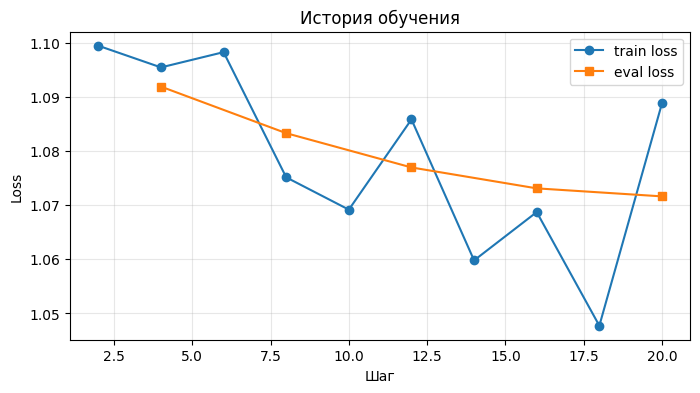

In [ ]:
# История логов Trainer.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 12. Оценка на `validation` и `test`

После fine-tuning нужно отдельно оценить качество на:

- `validation` – выборке, которая помогала контролировать обучение;
- `test` – полностью отложенной выборке.

Ниже дополнительно построим:

- `classification_report`;
- матрицу ошибок (`confusion matrix`).

> **Технический нюанс.** В Jupyter-окружении с `transformers >= 5.x` вызов `trainer.evaluate()`  
> вне тренировочного цикла падает с `RuntimeError` из-за `NotebookProgressCallback`.  
> Стандартный обходной путь – удалить этот коллбэк перед standalone-вызовом `evaluate()`.  
> Именно это делается в первых двух строках кода ниже.


In [ ]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")


Validation metrics:
eval_loss: 1.0832
eval_accuracy: 0.6667
eval_f1_macro: 0.5357
eval_f1_weighted: 0.5357
eval_runtime: 0.0158
eval_samples_per_second: 569.6460
eval_steps_per_second: 126.5880
epoch: 5.0000

Test metrics:
eval_loss: 1.0850
eval_accuracy: 0.6667
eval_f1_macro: 0.5556
eval_f1_weighted: 0.5556
eval_runtime: 0.0136
eval_samples_per_second: 662.1770
eval_steps_per_second: 147.1500
epoch: 5.0000


Classification report on test:
              precision    recall  f1-score   support

   education       0.00      0.00      0.00         3
      sports       1.00      1.00      1.00         3
  technology       0.50      1.00      0.67         3

    accuracy                           0.67         9
   macro avg       0.50      0.67      0.56         9
weighted avg       0.50      0.67      0.56         9



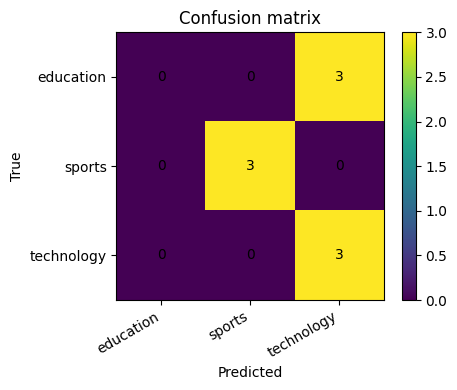

In [ ]:
# Детальные предсказания на тестовой выборке.
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 13. Проверка модели на новых текстах

Теперь используем дообученную модель на **новых текстах**, которых не было в обучении.

Это важный шаг:  
модель должна быть удобна не только для оценки на датасете, но и для применения к «обычным» пользовательским строкам.


In [ ]:
# Вспомогательная функция для инференса новых текстов.
def predict_texts(texts: List[str]) -> pd.DataFrame:
    encoded = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

    pred_ids = probs.argmax(axis=1)

    rows = []
    for text, pred_id, prob_vector in zip(texts, pred_ids, probs):
        row = {
            "text": text,
            "pred_label": id2label[int(pred_id)],
            "confidence": float(prob_vector[pred_id]),
        }
        for class_id, class_name in id2label.items():
            row[f"prob_{class_name}"] = float(prob_vector[class_id])
        rows.append(row)

    return pd.DataFrame(rows)

new_texts = [
    "На курсе подробно объяснили, как считать precision, recall и F1.",
    "Команда ускорила обработку запросов и уменьшила время отклика сервиса.",
    "В концовке матча нападающий забил победный гол.",
    "Студенты обсуждали архитектуру трансформеров и механизм attention.",
    "После обновления API приложение стало стабильнее работать на сервере.",
    "Тренер сообщил, что игрок вернётся в состав только после восстановления.",
]

display(predict_texts(new_texts))


,text,pred_label,confidence,prob_education,prob_sports,prob_technology
0,"На курсе подробно объяснили, как считать precision, recall и F1.",technology,0.3490,0.3278,0.3232,0.3490
1,Команда ускорила обработку запросов и уменьшила время отклика сервиса.,technology,0.3577,0.3233,0.3190,0.3577
2,В концовке матча нападающий забил победный гол.,sports,0.3488,0.3359,0.3488,0.3154
3,Студенты обсуждали архитектуру трансформеров и механизм attention.,technology,0.3510,0.3163,0.3327,0.3510
4,После обновления API приложение стало стабильнее работать на сервере.,technology,0.3421,0.3348,0.3231,0.3421
5,"Тренер сообщил, что игрок вернётся в состав только после восстановления.",technology,0.3381,0.3268,0.3352,0.3381


## 14. Разбор ошибок модели

Даже если итоговые метрики выглядят неплохо, полезно посмотреть,  
**на каких именно примерах модель ошибается**.

Это помогает понять:

- есть ли пересечение между классами;
- какие формулировки для модели особенно трудны;
- не переобучилась ли модель на слишком маленьком датасете.


In [ ]:
# Таблица ошибок на тестовой выборке.
test_texts = test_df.reset_index(drop=True)["text"]
error_rows = []

for text, true_id, pred_id, prob_vector in zip(test_texts, test_true, test_preds, torch.softmax(torch.tensor(test_logits), dim=-1).numpy()):
    if true_id != pred_id:
        error_rows.append({
            "text": text,
            "true_label": id2label[int(true_id)],
            "pred_label": id2label[int(pred_id)],
            "pred_confidence": float(prob_vector[pred_id]),
        })

errors_df = pd.DataFrame(error_rows)

if len(errors_df) == 0:
    print("На тестовой выборке ошибок не найдено. Это возможно на маленьком учебном датасете.")
else:
    display(errors_df.sort_values(by="pred_confidence", ascending=False).reset_index(drop=True))


,text,true_label,pred_label,pred_confidence
0,Школьники готовятся к олимпиаде по информатике и решают сложные задачи.,education,technology,0.3595
1,Программа дополнительного образования рассчитана на специалистов из отрасли.,education,technology,0.3530
2,"Преподаватель объяснил, как работает кросс-валидация на практических примерах.",education,technology,0.3441


## 15. Что влияет на качество

На практике качество fine-tuning зависит не только от самой архитектуры модели, но и от целого набора факторов.

### 15.1. Размер и качество датасета
Чем больше хороших размеченных примеров, тем устойчивее результат.  
Маленький учебный датасет подходит для демонстрации, но плохо отражает реальную сложность предметной области.

### 15.2. Качество разметки
Если классы размечены непоследовательно, модель начнёт учиться на шуме.

### 15.3. Баланс классов
Сильный дисбаланс по меткам может ухудшать качество на редких классах, даже если общая `accuracy` кажется высокой.

### 15.4. Размер модели
Более крупные модели могут давать лучшее качество, но требуют больше памяти и времени.

### 15.5. Параметры обучения
На результат влияют:
- `learning_rate`;
- число эпох;
- `batch_size`;
- `max_length`;
- регуляризация.

### 15.6. Близость домена
Если модель изначально предобучалась на текстах, похожих на ваш домен, fine-tuning обычно проходит легче.


## 16. Итоги

1. **Fine-tuning BERT-подобной модели** – это обычный инженерный pipeline: данные → токенизация → модель → обучение → оценка.
2. Для интеграции с экосистемой `transformers` удобно использовать `datasets.DatasetDict`, `AutoTokenizer`, `AutoModelForSequenceClassification` и `Trainer`.
3. Даже на небольшом учебном датасете можно пройти весь цикл и увидеть, как модель адаптируется под конкретные классы.
4. Итоговые метрики надо всегда сопровождать **анализом ошибок**, а не смотреть только на одно число `accuracy`.
5. Для реальных задач особенно важны размер датасета, качество разметки, баланс классов и корректный выбор модели.


## Задания для самостоятельной работы

1. Увеличьте или уменьшите число эпох и посмотрите, как меняются `train loss` и `eval loss`.
2. Попробуйте заменить модель `cointegrated/rubert-tiny2` на другую русскоязычную BERT-подобную модель и сравните результат.
3. Расширьте учебный датасет: добавьте ещё 10-15 текстов в каждый класс и повторите fine-tuning.
4. Измените число классов: например, выделите отдельно класс `science` или `business`.
5. Проверьте влияние `max_length`: попробуйте `64`, `128` и `256`.
6. Найдите несколько трудных примеров, на которых модель ошибается уверенно, и попытайтесь объяснить причину ошибки.
